# 02 — First Training Run

**Goal:** verify that the complete pipeline (environment + spiking actor-critic + R-STDP + backprop critic) can actually learn on a simple task.

**Task:** 5x5 gridworld, goal at (4,4), no obstacles, no noise. This is the simplest possible version — if the agent can't learn this, something is structurally broken.

**What we'll do:**

1. Baseline: random agent
2. Baseline: hand-coded greedy policy (upper bound for a naive non-learned policy)
3. Sanity check: confirm the untrained actor is producing spikes
4. Train the agent for 300 episodes
5. Plot learning curves (reward, steps-to-goal, success rate)
6. Plot diagnostics (spike counts, TD error, actor update magnitude)
7. Evaluate the trained agent vs. random
8. Interpretation

**Note:** This is a first-pass pipeline verification, not a final experiment. If learning works, we scale up to real experiments. If it fails, the diagnostics point to which module needs fixing.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from collections import deque
import json

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from spiking_rl.environment.gridworld import GridWorldEnv
from spiking_rl.learning.agent import AgentConfig, SpikingActorCriticAgent

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Torch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

d:\Research\reward-modulated-spiking-rl\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Torch: 2.14.0+cpu
CUDA: False


## 1. Baselines on the deterministic 5x5 gridworld

Before training anything, we establish what "doing nothing" and "following a hand-coded rule" look like. These are the reference points against which the trained agent will be judged.

In [2]:
# Fixed environment for all baselines and training. Same env config throughout.
def make_env() -> GridWorldEnv:
    return GridWorldEnv(
        size=5,
        start=(0, 0),
        goal=(4, 4),
        max_steps=100,
        step_reward=-0.01,
        render_mode=None,
    )

env = make_env()
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation space: Box(0.0, 1.0, (4,), float32)
Action space: Discrete(4)


In [4]:
print("Start:", env.start)
print("Goal:", env.goal)
env.render_mode = "ansi"
env.reset(seed=0)
print(env.render())

Start: [0 0]
Goal: [4 4]
 A  .  .  .  . 
 .  .  .  .  . 
 .  .  .  .  . 
 .  .  .  .  . 
 .  .  .  .  G 


In [5]:
# Build reverse mapping: direction (dr, dc) -> action index
_DIRECTION_TO_ACTION = {
    tuple(v): k for k, v in GridWorldEnv._ACTION_TO_DIRECTION.items()
}


def bfs_next_action(env):
    """Return the action that moves one step along the shortest path to the goal.

    Uses breadth-first search over the grid, respecting boundaries and
    obstacles. Returns None if the agent is already at the goal, or if
    no path exists.
    """
    start = (int(env._agent_pos[0]), int(env._agent_pos[1]))
    goal = (int(env.goal[0]), int(env.goal[1]))
    obstacles = env.obstacles
    size = env.size

    if start == goal:
        return None

    # BFS over grid cells.
    queue = deque([start])
    came_from = {start: None}
    came_from_action = {start: None}

    while queue:
        current = queue.popleft()
        if current == goal:
            break
        for action, delta in GridWorldEnv._ACTION_TO_DIRECTION.items():
            dr, dc = int(delta[0]), int(delta[1])
            nxt = (current[0] + dr, current[1] + dc)
            if not (0 <= nxt[0] < size and 0 <= nxt[1] < size):
                continue
            if nxt in obstacles:
                continue
            if nxt in came_from:
                continue
            came_from[nxt] = current
            came_from_action[nxt] = action
            queue.append(nxt)

    if goal not in came_from:
        return None  # no path (should not happen in our env)

    # Reconstruct path and return the first action taken.
    node = goal
    path_actions = []
    while came_from[node] is not None:
        path_actions.append(came_from_action[node])
        node = came_from[node]
    path_actions.reverse()
    return path_actions[0] if path_actions else None


def random_policy_episode(env, seed):
    """Run a random policy for one episode and return metrics."""
    obs, _ = env.reset(seed=seed)
    total_reward = 0.0
    steps = 0
    terminated = False
    truncated = False
    for _ in range(100):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        steps += 1
        if terminated or truncated:
            break
    return {
        "total_reward": total_reward,
        "steps": steps,
        "success": bool(terminated and not truncated),
    }


def optimal_policy_episode(env, seed):
    """Run the BFS-optimal policy for one episode."""
    obs, _ = env.reset(seed=seed)
    total_reward = 0.0
    steps = 0
    terminated = False
    truncated = False
    for _ in range(100):
        action = bfs_next_action(env)
        if action is None:
            action = 0  # agent already at goal; no-op
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        steps += 1
        if terminated or truncated:
            break
    return {
        "total_reward": total_reward,
        "steps": steps,
        "success": bool(terminated and not truncated),
    }


N_EVAL = 50
random_results = [random_policy_episode(env, seed=i) for i in range(N_EVAL)]
optimal_results = [optimal_policy_episode(env, seed=1000 + i) for i in range(N_EVAL)]

random_summary = {
    "mean_reward": float(np.mean([r["total_reward"] for r in random_results])),
    "success_rate": float(np.mean([r["success"] for r in random_results])),
    "mean_steps": float(np.mean([r["steps"] for r in random_results])),
}
optimal_summary = {
    "mean_reward": float(np.mean([r["total_reward"] for r in optimal_results])),
    "success_rate": float(np.mean([r["success"] for r in optimal_results])),
    "mean_steps": float(np.mean([r["steps"] for r in optimal_results])),
}

# Sanity: what is the BFS-optimal path length from start?
env.reset(seed=0)
optimal_action_sequence = []
for _ in range(50):
    a = bfs_next_action(env)
    if a is None:
        break
    optimal_action_sequence.append(a)
    _, _, term, trunc, _ = env.step(a)
    if term or trunc:
        break
print(f"BFS optimal path from start: {optimal_action_sequence}")
print(f"Optimal path length: {len(optimal_action_sequence)} steps")
print()

print(f"{'Policy':<20s} {'mean reward':>12s} {'success rate':>14s} {'mean steps':>12s}")
print("-" * 62)
print(f"{'random':<20s} {random_summary['mean_reward']:>12.3f} "
      f"{random_summary['success_rate']:>14.3f} {random_summary['mean_steps']:>12.1f}")
print(f"{'BFS-optimal':<20s} {optimal_summary['mean_reward']:>12.3f} "
      f"{optimal_summary['success_rate']:>14.3f} {optimal_summary['mean_steps']:>12.1f}")

BFS optimal path from start: [1, 1, 1, 1, 2, 2, 2, 2]
Optimal path length: 8 steps

Policy                mean reward   success rate   mean steps
--------------------------------------------------------------
random                     -0.147          0.580         73.3
BFS-optimal                 0.930          1.000          8.0


## 2. Sanity check: is the untrained actor firing?

Before spending time on training, we verify the actor is producing spikes. If it isn't, R-STDP can't update the output layer and training will produce no learning. This catches the dying-signal class of bugs immediately.

In [7]:
config = AgentConfig(
    actor_hidden=(64, 64),
    critic_hidden=(64, 64),
    decision_steps=5,
    eval_decision_steps=20,
    actor_lr=1e-3,
    critic_lr=1e-3,
    third_factor="td_error",
    log_every=25,
)

torch.manual_seed(SEED)
env = make_env()
agent = SpikingActorCriticAgent(env, config)

# Drive the actor with a batch of observations and count output spikes.
obs, _ = env.reset(seed=0)
obs_t = agent._to_tensor(obs)
agent.ac.reset()

spike_counts_over_time = []
for step in range(20):
    _, _, spike_counts = agent.ac.sample_action(obs_t)
    spike_counts_over_time.append(spike_counts.sum().item())

print("Actor output-layer spike counts over 20 forward passes:")
print(spike_counts_over_time)
print(f"Total spikes: {sum(spike_counts_over_time):.0f}")
print()
if sum(spike_counts_over_time) == 0:
    raise RuntimeError("Actor output layer is not firing. Training will not learn.")
else:
    print("✓ Actor is firing.")

Actor output-layer spike counts over 20 forward passes:
[3.0, 4.0, 3.0, 4.0, 4.0, 3.0, 4.0, 3.0, 4.0, 4.0, 4.0, 4.0, 4.0, 5.0, 4.0, 4.0, 4.0, 4.0, 4.0, 5.0]
Total spikes: 78

✓ Actor is firing.


## 3. First training run

300 episodes on the deterministic gridworld. Each episode uses a different seed so the initial position varies slightly (though here the start is fixed, so seeds mainly affect any internal randomness).

In [8]:
# Diagnostic: does the actor's output depend on the observation?

# Use the SAME environment as training
env_diag = make_env()

# Collect a batch of diverse observations by walking randomly.
observations = []
for seed in range(64):
    obs, _ = env_diag.reset(seed=seed)
    observations.append(obs)
    for _ in range(5):
        action = env_diag.action_space.sample()
        obs, _, term, trunc, _ = env_diag.step(action)
        observations.append(obs)
        if term or trunc:
            break

obs_batch = torch.tensor(np.array(observations[:64]), dtype=torch.float32)

# Fresh agent with the same config (avoid contaminating the training agent).
torch.manual_seed(SEED)
env_diag = make_env()
agent_diag = SpikingActorCriticAgent(env_diag, config)
agent_diag.ac.reset()

with torch.no_grad():
    spike_counts, _ = agent_diag.ac.actor(obs_batch, steps=5)

# Spike counts: shape (64, 4)
print("Spike counts across 64 observations:")
print(f"  shape: {spike_counts.shape}")
print(f"  min:   {spike_counts.min().item():.3f}")
print(f"  max:   {spike_counts.max().item():.3f}")
print(f"  mean:  {spike_counts.mean().item():.3f}")
print(f"  std:   {spike_counts.std().item():.3f}")
print()
print(f"Per-action std (how much each action varies across obs):")
for a in range(4):
    print(f"  action {a}: std = {spike_counts[:, a].std().item():.4f}")

# If the standard deviation is near zero, the actor is state-invariant.
# If it's substantial, the actor IS conditioning on the observation.
overall_std = spike_counts.std().item()
if overall_std < 0.1:
    print("\n⚠️  WARNING: Actor output is nearly constant across observations.")
    print("   The actor is not conditioning on the input. Reward shaping")
    print("   alone will not fix this. Consider increasing `tau`.")
else:
    print(f"\n✓ Actor output varies across observations (std = {overall_std:.3f}).")
    print("  The actor can condition on state. Reward shaping should help.")

Spike counts across 64 observations:
  shape: torch.Size([64, 4])
  min:   0.000
  max:   3.000
  mean:  0.645
  std:   0.837

Per-action std (how much each action varies across obs):
  action 0: std = 0.0000
  action 1: std = 0.0000
  action 2: std = 0.4407
  action 3: std = 0.4672

✓ Actor output varies across observations (std = 0.837).
  The actor can condition on state. Reward shaping should help.


In [9]:
config = AgentConfig(
    actor_hidden=(64, 64),
    critic_hidden=(64, 64),
    decision_steps=5,
    actor_lr=1e-3,
    critic_lr=1e-3,
    third_factor="td_error",
    log_every=25,
)

N_EPISODES = 300   

torch.manual_seed(SEED)
env = make_env()
print("Training env start:", env.start)

agent = SpikingActorCriticAgent(env, config)
history = agent.train(n_episodes=N_EPISODES, seed_start=0, verbose=True)
history_path = REPO_ROOT / "results" / "metrics" / "first_training_run.csv"
pd.DataFrame(history).to_csv(history_path, index=False)
print(f"Saved: {history_path}")

Training env start: [0 0]
Episode    25/300 | reward=-0.491 | spikes=   3.263 | td_err=+0.0146 | act_upd=0.3045 | div=1.2 | r0=0.001 r1=0.000 r2=0.000 | baseline=+0.000
Episode    50/300 | reward=-0.437 | spikes=   2.367 | td_err=+0.0115 | act_upd=0.2099 | div=1.1 | r0=0.001 r1=0.000 r2=0.000 | baseline=+0.000
Episode    75/300 | reward=+0.110 | spikes=   4.639 | td_err=+0.0339 | act_upd=0.3794 | div=1.3 | r0=0.001 r1=0.000 r2=0.001 | baseline=+0.000
Episode   100/300 | reward=+0.911 | spikes=  10.000 | td_err=+0.0279 | act_upd=0.1656 | div=1.0 | r0=0.001 r1=0.000 r2=0.001 | baseline=+0.000
Episode   125/300 | reward=+0.904 | spikes=  10.000 | td_err=+0.0055 | act_upd=0.0698 | div=1.0 | r0=0.001 r1=0.000 r2=0.001 | baseline=+0.000
Episode   150/300 | reward=+0.908 | spikes=  10.008 | td_err=+0.0022 | act_upd=0.0460 | div=1.0 | r0=0.001 r1=0.000 r2=0.001 | baseline=+0.000
Episode   175/300 | reward=+0.906 | spikes=   9.991 | td_err=+0.0023 | act_upd=0.0490 | div=1.1 | r0=0.001 r1=0.000 

In [10]:
diag = agent.diagnostics()
print("Actor layer diagnostics:")
for i, layer_info in enumerate(diag["actor_layers"]):
    print(f"  layer {i}: v_threshold={layer_info['v_threshold']:.4f}, "
          f"weight_norm_mean={layer_info['weight_norm_mean']:.4f}")

Actor layer diagnostics:
  layer 0: v_threshold=0.7108, weight_norm_mean=2.5106
  layer 1: v_threshold=0.6266, weight_norm_mean=2.5106
  layer 2: v_threshold=0.6336, weight_norm_mean=2.7789


## 4. Learning curves

Plot the raw episode-by-episode metrics and a smoothed trend line.

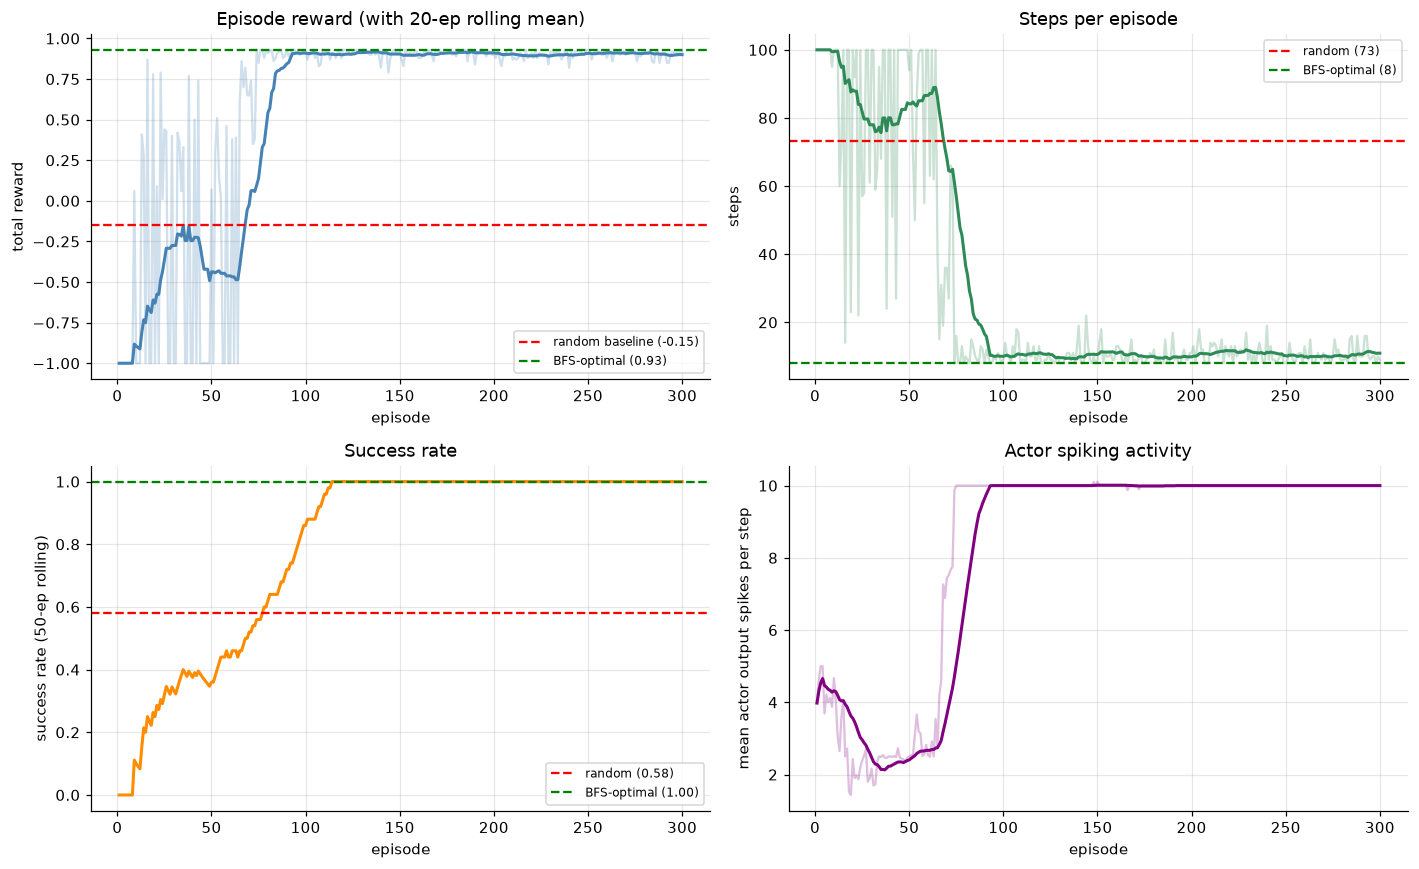

In [11]:
df = pd.DataFrame(history)


def smooth(x, window=20):
    return pd.Series(x).rolling(window=window, min_periods=1).mean().to_numpy()


fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# --- Panel 1: episode reward ---
ax = axes[0, 0]
ax.plot(df["episode"], df["total_reward"], alpha=0.25, color="steelblue")
ax.plot(df["episode"], smooth(df["total_reward"]), color="steelblue", linewidth=2)
ax.axhline(random_summary["mean_reward"], color="red", linestyle="--",
           label=f"random baseline ({random_summary['mean_reward']:.2f})")
ax.axhline(optimal_summary["mean_reward"], color="green", linestyle="--",
           label=f"BFS-optimal ({optimal_summary['mean_reward']:.2f})")
ax.set_xlabel("episode")
ax.set_ylabel("total reward")
ax.set_title("Episode reward (with 20-ep rolling mean)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Panel 2: steps per episode ---
ax = axes[0, 1]
ax.plot(df["episode"], df["steps"], alpha=0.25, color="seagreen")
ax.plot(df["episode"], smooth(df["steps"]), color="seagreen", linewidth=2)
ax.axhline(random_summary["mean_steps"], color="red", linestyle="--",
           label=f"random ({random_summary['mean_steps']:.0f})")
ax.axhline(optimal_summary["mean_steps"], color="green", linestyle="--",
           label=f"BFS-optimal ({optimal_summary['mean_steps']:.0f})")
ax.set_xlabel("episode")
ax.set_ylabel("steps")
ax.set_title("Steps per episode")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Panel 3: success over rolling window ---
ax = axes[1, 0]
success_rolling = smooth(df["success"].astype(float), window=50)
ax.plot(df["episode"], success_rolling, color="darkorange", linewidth=2)
ax.axhline(random_summary["success_rate"], color="red", linestyle="--",
           label=f"random ({random_summary['success_rate']:.2f})")
ax.axhline(optimal_summary["success_rate"], color="green", linestyle="--",
           label=f"BFS-optimal ({optimal_summary['success_rate']:.2f})")
ax.set_xlabel("episode")
ax.set_ylabel("success rate (50-ep rolling)")
ax.set_title("Success rate")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Panel 4: actor spikes per episode ---
ax = axes[1, 1]
ax.plot(df["episode"], df["mean_actor_spikes"], alpha=0.25, color="purple")
ax.plot(df["episode"], smooth(df["mean_actor_spikes"]), color="purple", linewidth=2)
ax.set_xlabel("episode")
ax.set_ylabel("mean actor output spikes per step")
ax.set_title("Actor spiking activity")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(REPO_ROOT / "results" / "figures" / "first_training_run.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 5. Diagnostic traces

The learning curves show whether performance improves. These diagnostics show *why* — or why not.

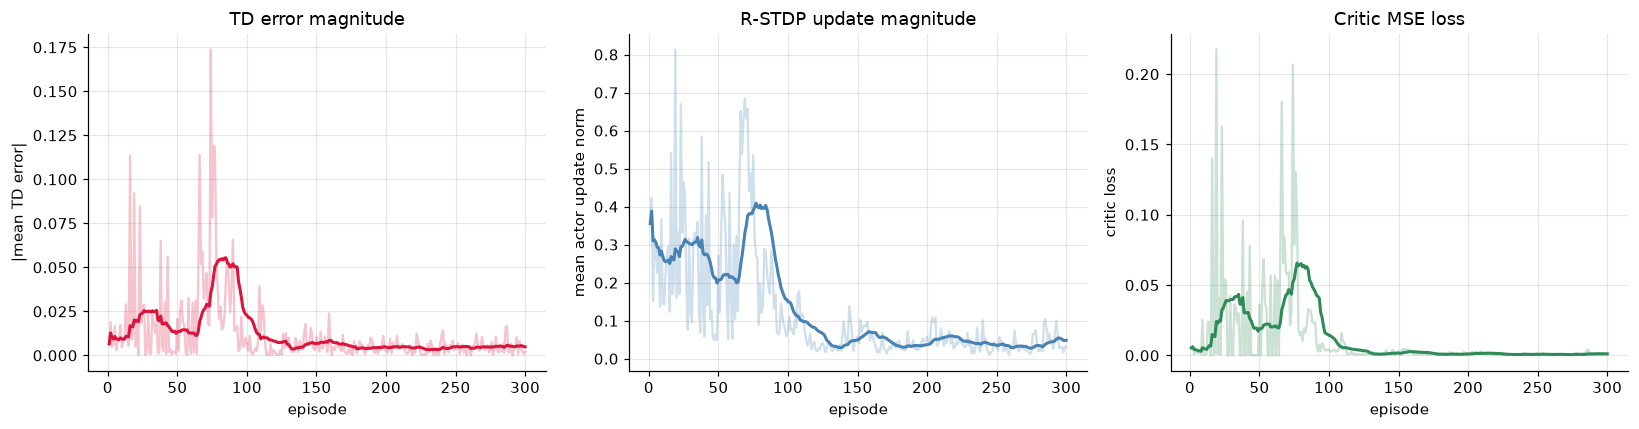

Diagnostic summary (last 50 episodes):
  mean reward:         +0.905
  success rate:        1.000
  mean actor spikes:   10.000
  mean |td error|:     0.0048
  mean actor update:   0.03931
  mean critic loss:    0.0009
  reward baseline:     +0.000


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- TD error magnitude ---
ax = axes[0]
ax.plot(df["episode"], np.abs(df["mean_td_error"]), alpha=0.25, color="crimson")
ax.plot(df["episode"], smooth(np.abs(df["mean_td_error"])),
        color="crimson", linewidth=2)
ax.set_xlabel("episode")
ax.set_ylabel("|mean TD error|")
ax.set_title("TD error magnitude")
ax.grid(alpha=0.3)

# --- Actor update magnitude ---
ax = axes[1]
ax.plot(df["episode"], df["mean_actor_update"], alpha=0.25, color="steelblue")
ax.plot(df["episode"], smooth(df["mean_actor_update"]),
        color="steelblue", linewidth=2)
ax.set_xlabel("episode")
ax.set_ylabel("mean actor update norm")
ax.set_title("R-STDP update magnitude")
ax.grid(alpha=0.3)

# --- Critic loss ---
ax = axes[2]
ax.plot(df["episode"], df["mean_critic_loss"], alpha=0.25, color="seagreen")
ax.plot(df["episode"], smooth(df["mean_critic_loss"]),
        color="seagreen", linewidth=2)
ax.set_xlabel("episode")
ax.set_ylabel("critic loss")
ax.set_title("Critic MSE loss")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics.
print("Diagnostic summary (last 50 episodes):")
tail = df.tail(50)
print(f"  mean reward:         {tail['total_reward'].mean():+.3f}")
print(f"  success rate:        {tail['success'].mean():.3f}")
print(f"  mean actor spikes:   {tail['mean_actor_spikes'].mean():.3f}")
print(f"  mean |td error|:     {tail['mean_td_error'].abs().mean():.4f}")
print(f"  mean actor update:   {tail['mean_actor_update'].mean():.5f}")
print(f"  mean critic loss:    {tail['mean_critic_loss'].mean():.4f}")
print(f"  reward baseline:     {tail['baseline'].iloc[-1]:+.3f}")

## 6. Evaluation vs. baselines

Run 100 evaluation episodes with the trained actor (greedy action selection, no learning, no noise).

In [14]:
greedy_eval = agent.evaluate(n_episodes=100, seed_start=10_000, greedy=True)
sampled_eval = agent.evaluate(n_episodes=100, seed_start=20_000, greedy=False)

print(f"{'Policy':<20s} {'mean reward':>12s} {'success rate':>14s} {'mean steps':>12s}")
print("-" * 62)
print(f"{'random':<20s} {random_summary['mean_reward']:>12.3f} "
      f"{random_summary['success_rate']:>14.3f} {random_summary['mean_steps']:>12.1f}")
print(f"{'BFS-optimal':<20s} {optimal_summary['mean_reward']:>12.3f} "
      f"{optimal_summary['success_rate']:>14.3f} {optimal_summary['mean_steps']:>12.1f}")
print(f"{'trained (greedy)':<20s} {greedy_eval['mean_reward']:>12.3f} "
      f"{greedy_eval['success_rate']:>14.3f} {greedy_eval['mean_steps']:>12.1f}")
print(f"{'trained (sampled)':<20s} {sampled_eval['mean_reward']:>12.3f} "
      f"{sampled_eval['success_rate']:>14.3f} {sampled_eval['mean_steps']:>12.1f}")

eval_path = REPO_ROOT / "results" / "metrics" / "first_training_run_eval.json"
with open(eval_path, "w") as f:
    json.dump(
        {
            "mean_reward": float(sampled_eval["mean_reward"]),
            "success_rate": float(sampled_eval["success_rate"]),
            "mean_steps": float(sampled_eval["mean_steps"]),
            "n_episodes": int(sampled_eval["n_episodes"]),
        },
        f,
        indent=2,
    )
print(f"Saved: {eval_path}")

Policy                mean reward   success rate   mean steps
--------------------------------------------------------------
random                     -0.147          0.580         73.3
BFS-optimal                 0.930          1.000          8.0
trained (greedy)           -1.000          0.000        100.0
trained (sampled)           0.910          1.000         10.0
Saved: d:\Research\reward-modulated-spiking-rl\results\metrics\first_training_run_eval.json


In [15]:
# Cell A: Does greedy action vary across states?
env_diag = make_env()
env_diag.reset(seed=0)
observations = []
for _ in range(500):
    action = env_diag.action_space.sample()
    obs, _, term, trunc, _ = env_diag.step(action)
    observations.append(obs)
    if term or trunc:
        env_diag.reset(seed=0)
observations = observations[:128]
obs_batch = torch.tensor(np.array(observations), dtype=torch.float32)

torch.manual_seed(SEED)
agent_for_diag = SpikingActorCriticAgent(make_env(), config)
agent_for_diag.ac.load_state_dict(agent.ac.state_dict())  # use trained weights

with torch.no_grad():
    spike_counts, _ = agent_for_diag.ac.actor(obs_batch, steps=5)
    greedy_actions = spike_counts.argmax(dim=-1)

unique, counts = greedy_actions.unique(return_counts=True)
print("Greedy action distribution across 128 random observations:")
for u, c in zip(unique.tolist(), counts.tolist()):
    print(f"  action {u}: {c} times ({100*c/len(greedy_actions):.1f}%)")
print(f"\nUnique greedy actions: {unique.tolist()}")

Greedy action distribution across 128 random observations:
  action 1: 128 times (100.0%)

Unique greedy actions: [1]


In [16]:
# Cell B: Compare greedy vs sampling evaluation
greedy_eval = agent.evaluate(n_episodes=50, greedy=True)
sampled_eval = agent.evaluate(n_episodes=50, greedy=False)

print(f"Greedy eval:  reward={greedy_eval['mean_reward']:+.3f}  "
      f"success={greedy_eval['success_rate']:.3f}  steps={greedy_eval['mean_steps']:.1f}")
print(f"Sampled eval: reward={sampled_eval['mean_reward']:+.3f}  "
      f"success={sampled_eval['success_rate']:.3f}  steps={sampled_eval['mean_steps']:.1f}")

Greedy eval:  reward=-1.000  success=0.000  steps=100.0
Sampled eval: reward=+0.905  success=1.000  steps=10.5


In [17]:
# Cell C: How spread are the spike counts?
with torch.no_grad():
    spike_counts, _ = agent_for_diag.ac.actor(obs_batch, steps=5)
    sorted_counts, _ = spike_counts.sort(dim=-1, descending=True)
    margin = sorted_counts[:, 0] - sorted_counts[:, 1]
    print(f"Top-vs-second spike count margin across obs:")
    print(f"  mean: {margin.mean().item():.4f}")
    print(f"  std:  {margin.std().item():.4f}")
    print(f"  min:  {margin.min().item():.4f}")
    print(f"  max:  {margin.max().item():.4f}")
    print(f"  fraction with margin < 0.1: {(margin < 0.1).float().mean().item():.3f}")

Top-vs-second spike count margin across obs:
  mean: 0.0000
  std:  0.0000
  min:  0.0000
  max:  0.0000
  fraction with margin < 0.1: 1.000


## 7. Interpretation

Fill in the blanks based on what you saw in the plots above.

### If the trained agent beats random but not greedy:
**Expected.** 300 episodes is short and the network has to discover the goal from scratch. The result "learns faster than random" is exactly what we want to see at this stage. We extend training and add noise in later experiments.

### If the trained agent matches or beats greedy:
**Very good.** The spiking actor has learned the optimal policy. Note that greedy is optimal on the deterministic 5x5 grid, so the ceiling is `1.0` success rate. If we're close, the pipeline works.

### If the trained agent does not beat random:
**Structural problem.** Check the diagnostic plots:

- If `mean actor spikes` is ~0 → the actor is not firing, no eligibility, no learning. Revisit the SNN init or the threshold.
- If `mean actor update` is ~0 → the modulation signal is zero. Check TD error.
- If `mean |td error|` decreases but reward doesn't improve → the critic is learning but the actor is not.
- If critic loss explodes → gradient issue. Reduce `critic_lr` or increase gradient clipping.

In [ ]:
# Save the history for later reference.
history_path = REPO_ROOT / "results" / "metrics" / "first_training_run.csv"
df.to_csv(history_path, index=False)
print(f"Saved history to: {history_path}")